In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os
import csv
import pandas as pd

import scipy.stats
from sklearn.linear_model import LinearRegression

import torch
from networks_update import Encoder, Decoder
import math
import random

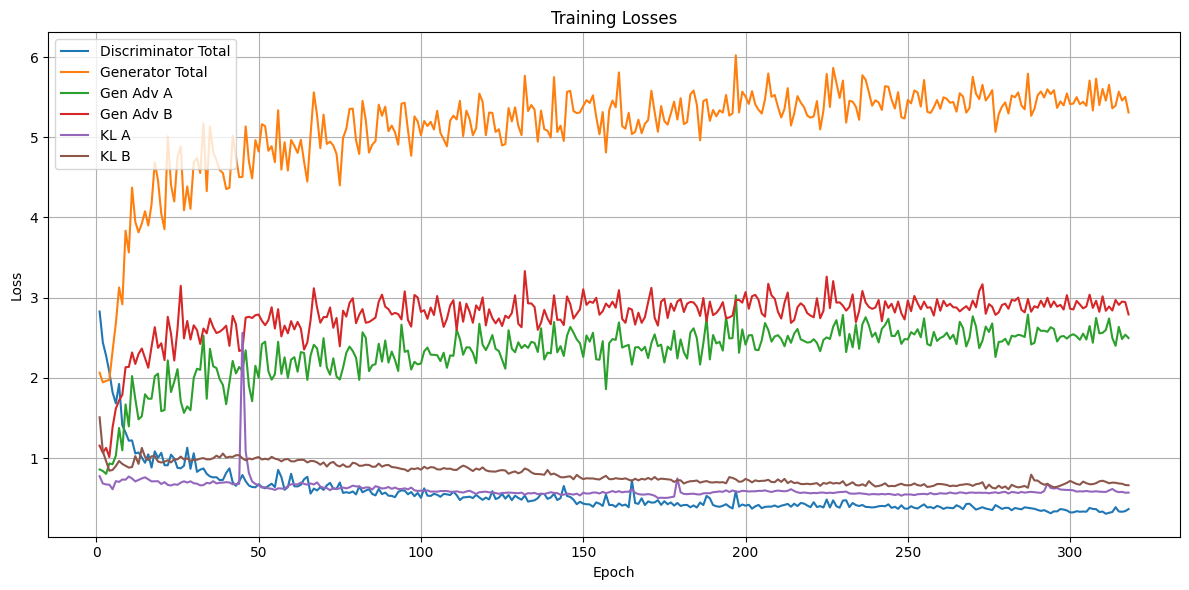

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV data
csv_path = './logs/unit_mouse2human_folder/loss.csv'  # <-- update with your actual file path
df = pd.read_csv(csv_path)

# Optional: Clean column names if needed (e.g., strip whitespace)
df.columns = [col.strip() for col in df.columns]

# Plot selected loss terms
plt.figure(figsize=(12, 6))

epochs = df['iteration'] / 55

# Example: Plot generator and discriminator losses
plt.plot(epochs, df['loss_dis_total'], label='Discriminator Total')
plt.plot(epochs, df['loss_gen_total'], label='Generator Total')
plt.plot(epochs, df['loss_gen_adv_a'], label='Gen Adv A')
plt.plot(epochs, df['loss_gen_adv_b'], label='Gen Adv B')
plt.plot(epochs, df['loss_gen_recon_kl_a'], label='KL A')
plt.plot(epochs, df['loss_gen_recon_kl_b'], label='KL B')

# Customize
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

/tmp/ipykernel_10215/1892478328.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', num_lines)


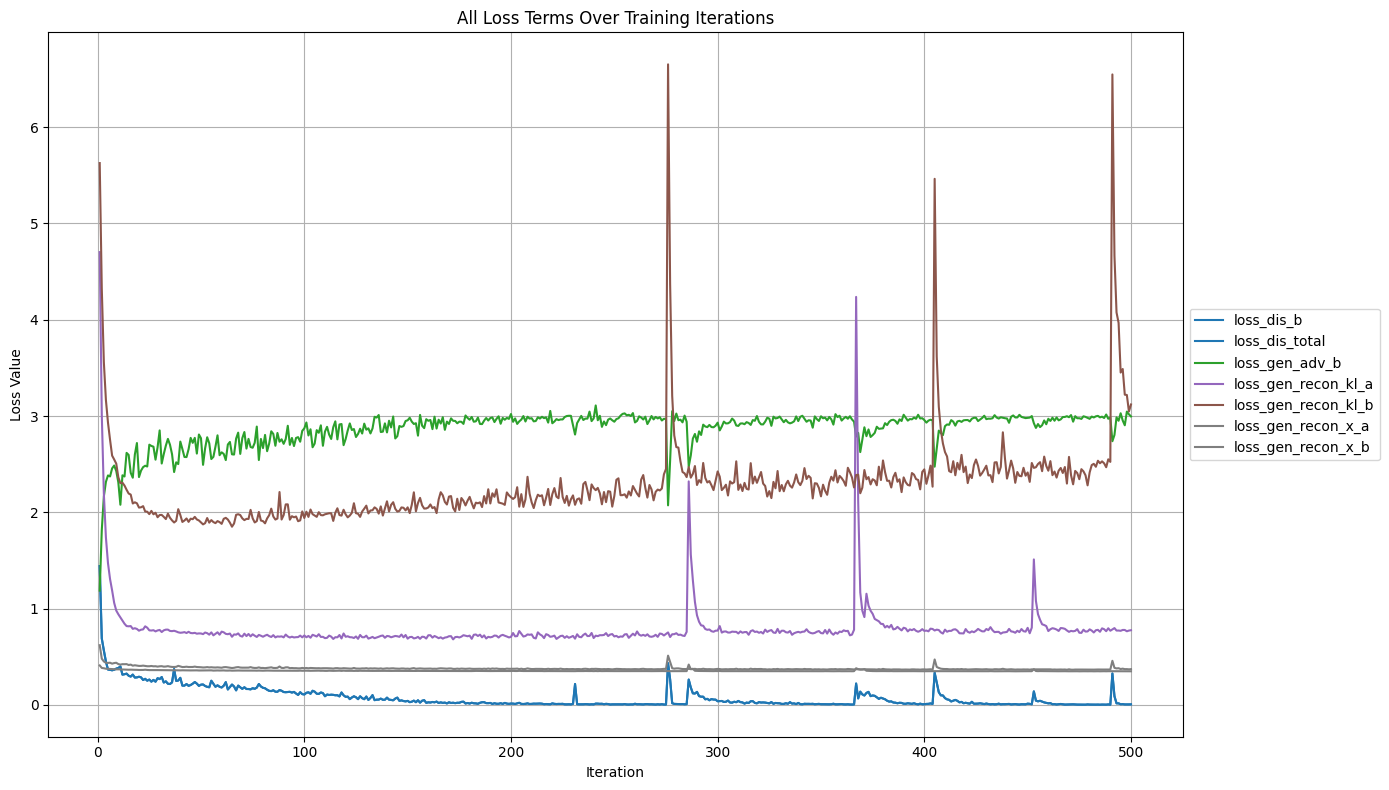

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Path to your CSV file
csv_path = './outputs/unit_mouse2human_train_3_CE_folder/loss.csv'  # Update this to your actual file path

df = pd.read_csv(csv_path)

# Clean up column names
df.columns = [col.strip() for col in df.columns]
loss_columns = [col for col in df.columns if col != 'iteration']

# Prepare distinct colors
num_lines = len(loss_columns)
colors = cm.get_cmap('tab10', num_lines)
epochs = df['iteration'] / 55


# Plot
plt.figure(figsize=(14, 8))
for i, col in enumerate(loss_columns):
    if df[col][5] != 0 and df[col][5] < 10:
        plt.plot(epochs, df[col], label=col, color=colors(i))

plt.xlabel('Iteration')
plt.ylabel('Loss Value')
plt.title('All Loss Terms Over Training Iterations')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()

plt.show()

# a whole bunch of losses are 0???

In [4]:
# Evaluate models at epoch 300 (on CPU to not clash with training)
from utils import get_all_data_loaders, prepare_sub_folder, write_html, write_loss, write_loss_to_csv, get_config, write_2images, Timer
import argparse
from torch.autograd import Variable
from trainer_3d import MUNIT_Trainer, UNIT_Trainer
import torch.backends.cudnn as cudnn
import torch
try:
    from itertools import izip as zip
except ImportError: # will be 3.x series
    pass
import os
import sys
import tensorboardX
import shutil
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import SimpleITK as sitk
import numpy as np
import torchvision.utils as vutils


class Segmentation3DDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform  # Optional (e.g., normalization, crop)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = sitk.ReadImage(self.image_paths[idx])
        image = sitk.GetArrayFromImage(image)

        # Add channel dimension if needed (C x D x H x W)
        if image.ndim == 3:
            image = np.expand_dims(image, axis=0)
        
        if self.transform:
            image = self.transform(image)

        return torch.from_numpy(image).to(torch.float)


config='configs/unit_mouse2human_folder.yaml'
output_path='.'
resume="store_true"
trainer='UNIT'

cudnn.benchmark = True

# Load experiment setting
config = get_config(config)
max_iter = config['max_iter']
display_size = config['display_size']
config['vgg_model_path'] = output_path

# Setup model and data loader
if trainer == 'MUNIT':
    trainer = MUNIT_Trainer(config)
elif trainer == 'UNIT':
    trainer = UNIT_Trainer(config)
else:
    sys.exit("Only support MUNIT|UNIT")
trainer.cuda()

# Dataset path
train_folder_mouse = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
train_paths_mouse = [train_folder_mouse + file_name for file_name in os.listdir(train_folder_mouse)]

val_folder_mouse = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/images/"
val_paths_mouse = [val_folder_mouse + file_name for file_name in os.listdir(val_folder_mouse)]
val_paths_mouse.sort()

train_folder_human = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/labels/"
train_paths_human = [train_folder_human + file_name for file_name in os.listdir(train_folder_human)]

val_folder_human = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/labels/"
val_paths_human = [val_folder_human + file_name for file_name in os.listdir(val_folder_human)]
val_paths_human.sort()

train_dataset_mouse = Segmentation3DDataset(image_paths=train_paths_mouse)
test_dataset_mouse = Segmentation3DDataset(image_paths=val_paths_mouse)
train_dataset_human = Segmentation3DDataset(image_paths=train_paths_human)
test_dataset_human = Segmentation3DDataset(image_paths=val_paths_human)

train_loader_a = DataLoader(train_dataset_mouse, batch_size=1, shuffle=True)
train_loader_b = DataLoader(train_dataset_human, batch_size=1, shuffle=True)
test_loader_a = DataLoader(test_dataset_mouse, batch_size=1, shuffle=False)
test_loader_b = DataLoader(test_dataset_human, batch_size=1, shuffle=False)

train_display_images_a = torch.stack([train_loader_a.dataset[i] for i in range(display_size)]).cuda()
train_display_images_b = torch.stack([train_loader_b.dataset[i] for i in range(display_size)]).cuda()
test_display_images_a = torch.stack([test_loader_a.dataset[i] for i in range(display_size)]).cuda()
test_display_images_b = torch.stack([test_loader_b.dataset[i] for i in range(display_size)]).cuda()


# Write images
image_directory = "./outputs/unit_mouse2human_folder/images/"

def __write_images(image_outputs, display_image_num, file_name):
    #image_outputs = [images.expand(-1, 3, -1, -1) for images in image_outputs] # expand gray-scale images to 3 channels
    slice_idx = image_outputs[0].shape[2] // 2
    image_outputs = [img[:, :, slice_idx, :, :] for img in image_outputs]
    image_tensor = torch.cat([images[:display_image_num] for images in image_outputs], 0)
    image_grid = vutils.make_grid(image_tensor.data, nrow=display_image_num, padding=0, normalize=True)
    vutils.save_image(image_grid, file_name, nrow=1)

def write_2images(image_outputs, display_image_num, image_directory, postfix):
    n = len(image_outputs)
    __write_images(image_outputs[0:n//2], display_image_num, '%s/gen_a2b_%s.jpg' % (image_directory, postfix))
    __write_images(image_outputs[n//2:n], display_image_num, '%s/gen_b2a_%s.jpg' % (image_directory, postfix))


with torch.no_grad():
    test_image_outputs = trainer.sample(test_display_images_a, test_display_images_b)
    train_image_outputs = trainer.sample(train_display_images_a, train_display_images_b)
write_2images(test_image_outputs, display_size, image_directory, 'test_epoch_300')
write_2images(train_image_outputs, display_size, image_directory, 'test_epoch_300')

# HTML
#write_html(output_directory + "/index.html", iterations + 1, config['image_save_iter'], 'images')

with torch.no_grad():
    image_outputs = trainer.sample(train_display_images_a, train_display_images_b)
write_2images(image_outputs, display_size, image_directory, 'train_current')
